# Customer Segmentation Analysis for Enhanced Marketing Strategies

In [21]:
df.head(5)

,Gender,Marital Status,Education,Settlement Size,Occupation,Income,Age
0,0,0,3,2,2,185611,50
1,0,1,1,0,1,114778,30
2,0,1,1,0,0,132788,34
3,0,1,3,2,2,209671,55
4,1,1,1,2,1,118593,44


In [22]:
df.tail(5)

,Gender,Marital Status,Education,Settlement Size,Occupation,Income,Age
1995,0,1,3,2,2,218816,57
1996,0,1,1,0,1,118930,31
1997,0,1,1,0,1,150724,38
1998,0,1,1,0,1,141251,36
1999,1,0,3,1,1,84080,28


In [25]:
print(df.shape)

(2000, 7)


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Gender           2000 non-null   int64
 1   Marital Status   2000 non-null   int64
 2   Education        2000 non-null   int64
 3   Settlement Size  2000 non-null   int64
 4   Occupation       2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Age              2000 non-null   int64
dtypes: int64(7)
memory usage: 109.5 KB


**Description of variables:**
|Variable|Data type|Range|Description
| ---| --- | --- | --- |
| `Gender` | Nominal |{0,1}|Biological sex (gender) of a customer. In this dataset, there are only 2 different options as `0` is male, `1` is female |
| `Marital Status` | Nominal |{0,1}|Marital status of a customer as `0` is single, `1` is non-single (divorced / separated / married / widowed) |
| `Age` | Numerical |Integer|The age of the customer in years, calculated as current year minus the year of birth of the customer at the time of creation of the dataset |
| `Education` | Ordinal |{0,1,2,3} | Level of education of the customer as `0` is other / unknown, `1` is high school, `2` is university and `3` is graduate school |
| `Income` | Numerical |Real|Self-reported annual income in US dollars of the customer|
| `Occupation` | Nominal |{0,1,2}|Category of occupation of the customer as `0` is unemployed / unskilled, `1` is skilled employee / official, `2` is management / self-employed / highly qualified employee / officer |
| `Settlement Size` | Ordinal |{0,1,2} |The size of the city that the customer lives in as `0` is small city, `1` is mid-sized city, `2` is big city |

**Checking missing values**

In [31]:
missing_values = df.isnull().sum()
pd.DataFrame(missing_values, columns=['Missing Values'])

,Missing Values
Gender,0
Marital Status,0
Education,0
Settlement Size,0
Occupation,0
Income,0
Age,0


**Comment on missing values**: 
- There are no missing values in any of the variables. This completeness ensures that our dataset is ready for analysis and modeling without the need for imputation or additional data cleaning steps related to missing data.
- Having no missing values is advantageous as it simplifies the preprocessing workflow and enhances the robustness of the clustering results. It allows for a more straightforward interpretation of the cluster characteristics and ensures that all observations contribute equally to the analysis.


**Correlation matrix**

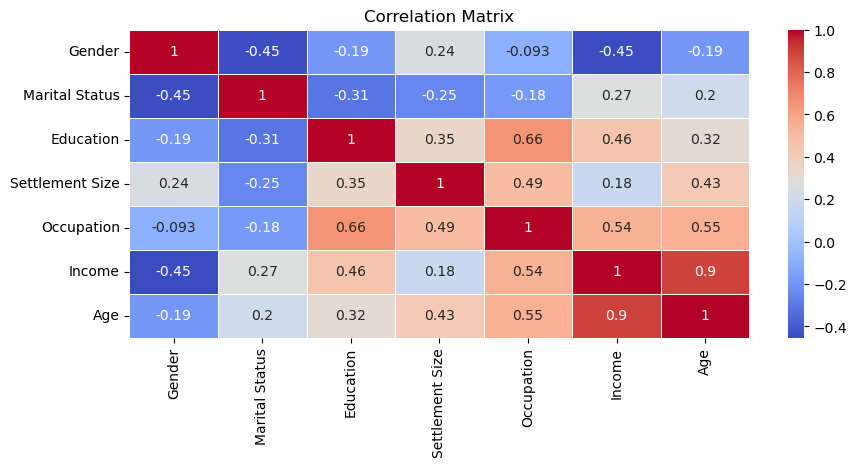

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

**Comment on correlation matrix:** The correlation matrix visualizes the relationships between variables in the dataset, with correlation values ranging from -1 to 1. Here's a breakdown of key relationships:
- There are strong to moderate positive correlations between Income and Age (0.9), Education and Occupation (0.66), Occupation and Income (0.54), Settlement Size and Occupation (0.49), Education and Income (0.46), and Education and Settlement Size (0.35). These relationships suggest that as customers age and attain higher education levels, they tend to hold higher-level occupations with greater incomes and are more likely to reside in larger cities.
  
- Marital Status and Gender (-0.45) and Gender and Income (-0.45): Both show moderate negative correlations, suggesting that males are more likely to be single and may earn more than females, indicating a potential gender income gap where females are more likely to be non-single and have lower incomes.



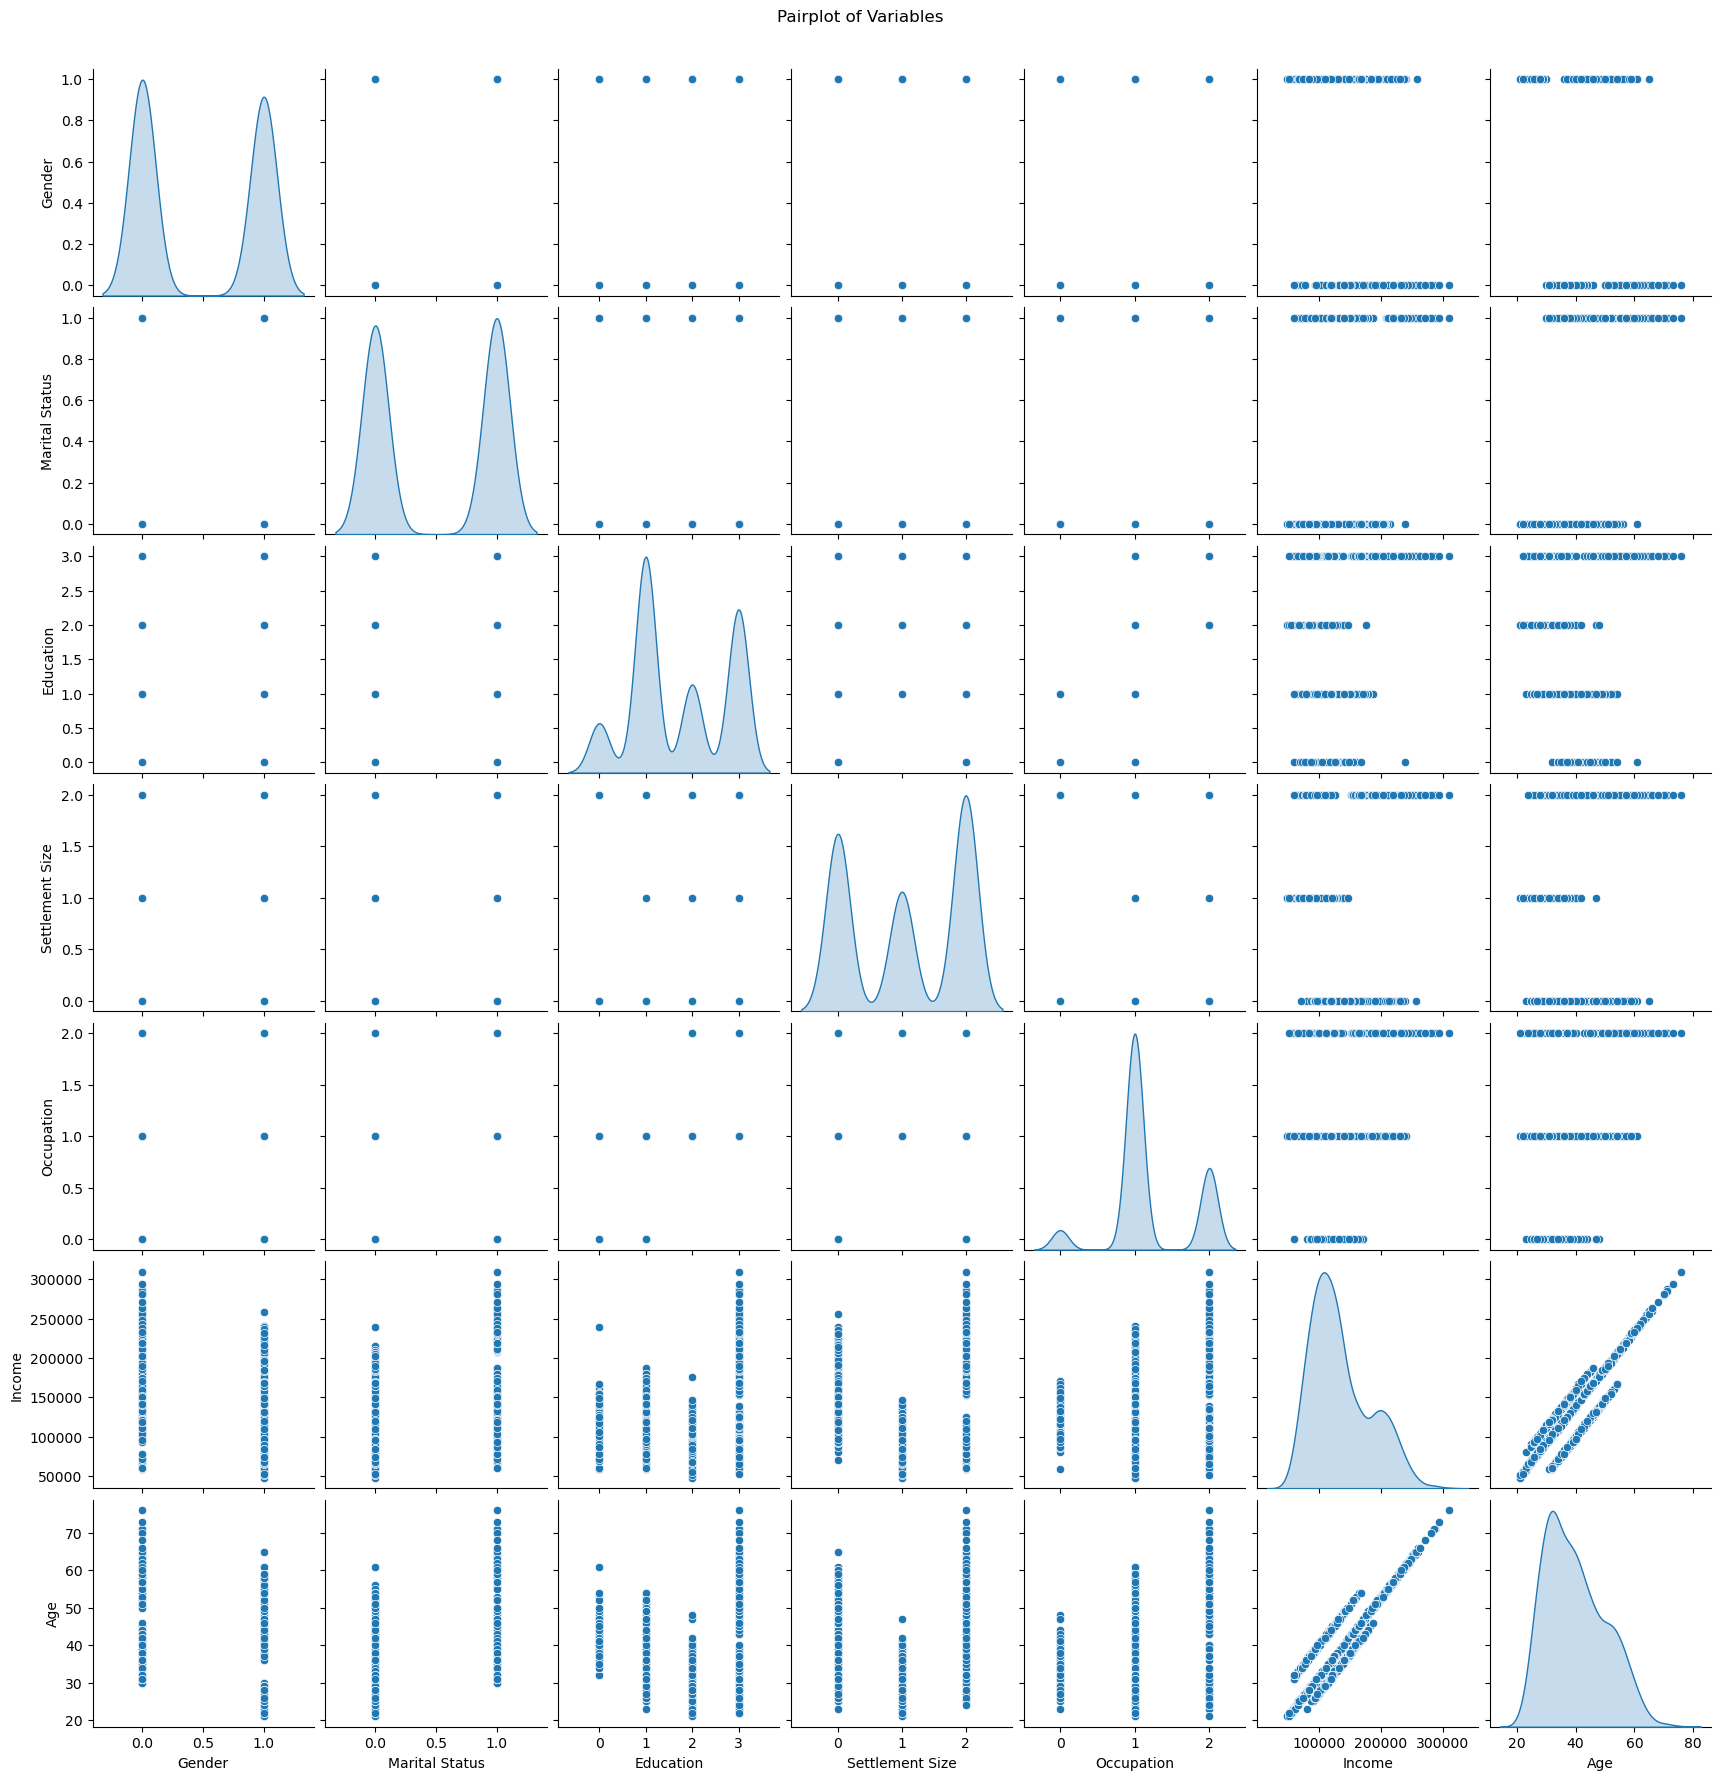

In [75]:
sns.pairplot(df, diag_kind='kde')
plt.suptitle('Pairplot of Variables', y=1.02)  # Adjust title position
plt.show()

### Descriptive statictics

**Numerical Variables**

In [56]:
df[['Age', 'Income']].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2000.0,39.8595,10.159890,21.0,32.0,38.0,47.0,76.0
Income,2000.0,134526.0545,47800.531778,47825.0,98408.0,123258.0,164973.0,309364.0



**The descriptive statistics for numeric variables show the following:**

- **Age**: The average customer age is 39.86 years, with a standard deviation of 10.16, indicating a relatively wide spread. The youngest customer is 21 years old, while the oldest is 76. The interquartile range (IQR) spans from 32 to 47, with a median of 38 years.

- **Income**: The mean income is 134,526, with a high standard deviation of 47,800, reflecting significant income variability. The minimum income is 47,825, while the maximum reaches 309,364. The IQR ranges from 98,408 to 164,973, with a median income of 123,258, indicating that most customers earn between these values.

**Categorical Variables**

In [61]:
categorical_vars = ['Gender', 'Marital Status', 'Education', 'Settlement Size', 'Occupation']

# Convert the specified variables to object type
for var in categorical_vars:
    if var in df.columns:
        df[var] = df[var].astype('object')

df[categorical_vars].describe()

,Gender,Marital Status,Education,Settlement Size,Occupation
count,2000,2000,2000,2000,2000
unique,2,2,4,3,3
top,0,1,1,2,1
freq,1041,1017,836,842,1362


**The descriptive statistics for categorical variables show the following:**

- **Gender**: There are 2 unique categories. The most frequent category is `male`. This means 1,041 customers are male, and the remaining 959 are female.
- **Marital Status**: There are 2 unique categories. The most frequent category is `non-single`. This suggests a slightly higher proportion of non-single customers compared to single ones.
- **Education**: There are 4 unique categories. The most frequent category is `high school`. This indicates that high school is the most common education level among customers.
- **Settlement Size**: There are 3 unique categories. The most frequent category is `big city`. This implies that most customers live in big cities.
- **Occupation**: There are 3 unique categories. The most frequent category is `skilled employee/official`. This shows that the majority of customers are skilled employees or officials.

### Analysis of Numerical Variables 

**Age distribution**

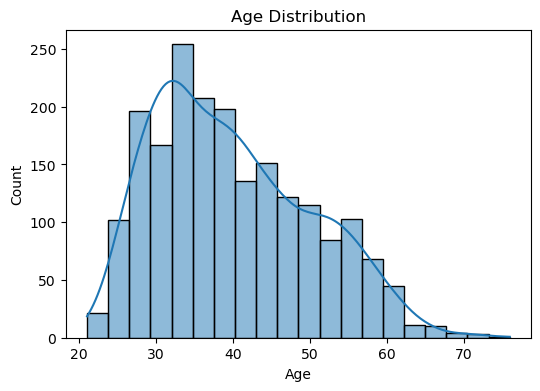

In [49]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Age'], kde=True, bins=20)
plt.title('Age Distribution')
plt.show()

**Comments:** The age distribution of the 2,000 customers is right-skewed, with more younger customers than older ones. Most customers are between 20 and 50, peaking between 30 and 40 and then the frequency gradually decreases as age increases. This suggests that marketing and product strategies should focus on middle-aged and younger customers.

**Income distribution**

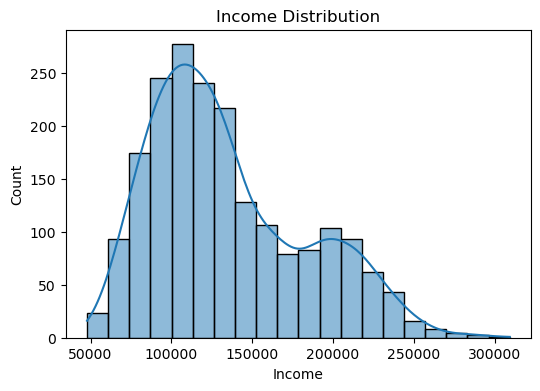

In [53]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Income'], kde=True, bins=20)
plt.title('Income Distribution')
plt.show()

**Comments:** The income distribution of customers shows a right-skewed pattern, with the majority earning between 75,000 and 125,000. Fewer customers earn beyond 200,000, and the distribution tails off at the higher end, approaching 300,000. This suggests that most customers at the supermarket chain fall into a middle-income range, with a smaller percentage of higher-income earners.






### Analysis of Categorical Variables

**Gender Distribution**

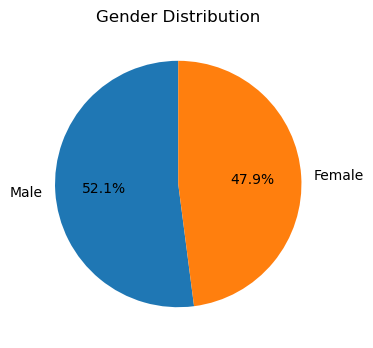

In [138]:
gender_counts = df['Gender'].value_counts()
mylabels = ["Male", "Female"]
plt.figure(figsize=(4, 4))
plt.pie(gender_counts, labels=mylabels,autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.show()

**Distribution of Marital Status**

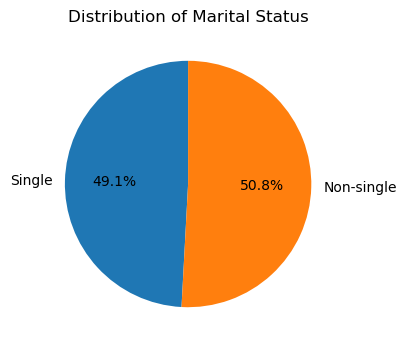

In [141]:
plt.figure(figsize=(4, 4))
marital_counts = df['Marital Status'].value_counts()
marital_counts = marital_counts.sort_index()
marital_lables = ["Single", "Non-single"]
plt.pie(marital_counts, labels=marital_lables, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Marital Status')
plt.show()

**Comments:** The gender distribution is nearly equal, with 52.1% male and 47.9% female. Similarly, marital status is almost evenly split between single (49.1%) and non-single (50.8%) customers.

**Distribution of Education Levels**

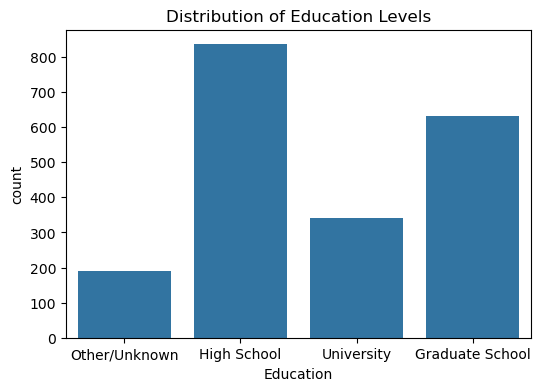

In [144]:
df['Education'] = df['Education'].map({0: 'Other/Unknown', 1: 'High School', 2: 'University', 3: 'Graduate School'})
plt.figure(figsize=(6, 4))
sns.countplot(x='Education', data=df, order=['Other/Unknown', 'High School', 'University', 'Graduate School'])
plt.title('Distribution of Education Levels')
plt.show()

Most customers have a high school education, followed by a sizable group with graduate-level education. University-educated customers make up a smaller proportion.

**Distribution of Occupation**

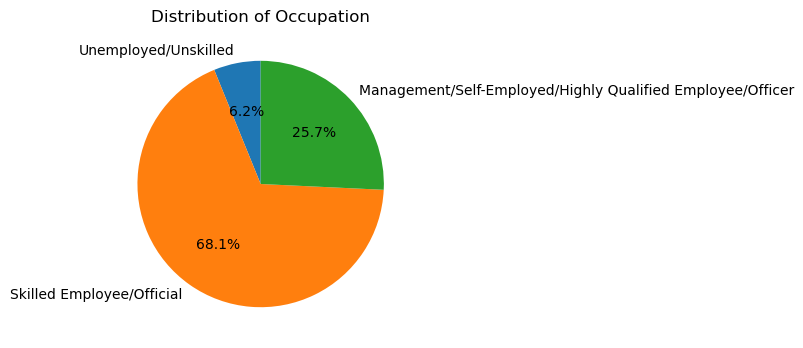

In [147]:
plt.figure(figsize=(4, 4))
occupation_counts = df['Occupation'].value_counts()
occupation_counts = occupation_counts.sort_index()
occupation_lables = ["Unemployed/Unskilled", "Skilled Employee/Official", "Management/Self-Employed/Highly Qualified Employee/Officer"]
plt.pie(occupation_counts, labels=occupation_lables, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Occupation')
plt.show()

The majority of customers (68.1%) are skilled employees or officials, while 25.7% are in management or highly qualified roles. A small proportion (6.2%) are unemployed or unskilled.

**Distribution of Settlement Size**

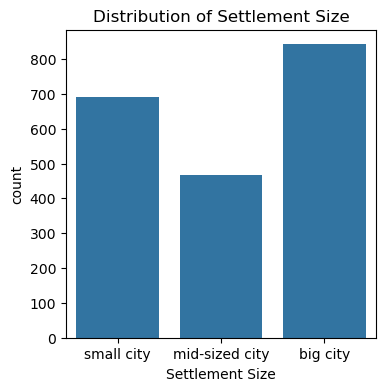

In [150]:
df['Settlement Size'] = df['Settlement Size'].map({0: 'small city', 1: 'mid-sized city', 2: 'big city'})
plt.figure(figsize=(4, 4))
sns.countplot(x='Settlement Size', data=df, order=['small city','mid-sized city','big city'])
plt.title('Distribution of Settlement Size')
plt.show()

The largest proportion of customers live in big cities, followed by small cities, while fewer are from mid-sized cities.

## Customer Segmentation

### Choosing the optimal number of customer segments/clusters using the Elbow Method

In [56]:
data = df.copy()

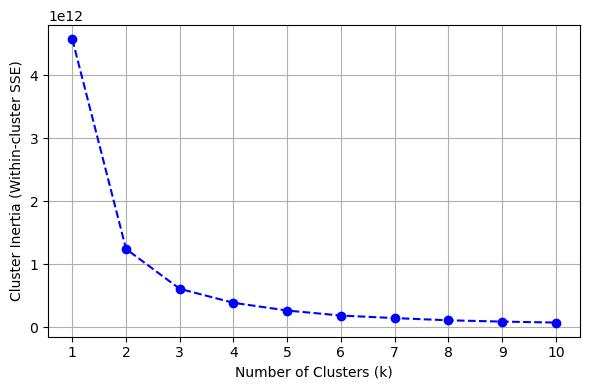

In [58]:
from sklearn.cluster import KMeans

# Elbow method using inertias
inertias = []  # To store the inertia for each number of clusters

# Loop over a range of cluster numbers (1 to 10) and calculate inertia
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=300, random_state=0)
    km.fit(data)  # Fitting KMeans to the data
    inertias.append(km.inertia_)  # Storing the inertia value

# Plotting the elbow plot
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), inertias, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Cluster Inertia (Within-cluster SSE)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.tight_layout()
plt.show()


It looks like the "elbow" in the plot appears to be at k = 3, suggesting that the optimal number of clusters is 3.

**KMeans++**

In [63]:
# Apply KMeans++ with 3 clusters
km_plus = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=300, random_state=0)
y_km_plus = km_plus.fit_predict(data)

# Display cluster centers and customer counts
print("KMeans++ Cluster Centers:\n", km_plus.cluster_centers_)
print("Customer counts in each cluster:\n", pd.Series(y_km_plus).value_counts())

KMeans++ Cluster Centers:
 [[7.38406659e-01 2.77051130e-01 1.54458977e+00 1.25564804e+00
  1.04518430e+00 9.24439893e+04 3.24708680e+01]
 [2.05949657e-01 4.82837529e-01 2.95881007e+00 1.78489703e+00
  1.87414188e+00 2.09584346e+05 5.47940503e+01]
 [3.43490305e-01 7.93628809e-01 1.13850416e+00 4.34903047e-01
  9.61218837e-01 1.38114065e+05 3.94265928e+01]]
Customer counts in each cluster:
 0    841
2    722
1    437
Name: count, dtype: int64


In [100]:
variables = ['Gender', 'Marital Status', 'Education', 'Settlement Size', 'Occupation', 'Income', 'Age']

# Cluster centers from KMeans++ (3 clusters)
cluster_centers = km_plus.cluster_centers_

# Convert the cluster centers into a DataFrame
cluster_centers_df = pd.DataFrame(cluster_centers, columns=variables)

# Get customer counts for each cluster
customer_counts = pd.Series(y_km_plus).value_counts()

# Add customer counts as a new row to the DataFrame
cluster_centers_df['Customer Count'] = customer_counts.values

# Display the final table with cluster centers and customer counts
formatted_cluster_centers = cluster_centers_df.T
formatted_cluster_centers.columns = [f"Cluster {i}" for i in range(cluster_centers.shape[0])]

print("\nTable of KMeans++ Clustering Cluster Centers and Customer Counts for each cluster\n")
print(formatted_cluster_centers)



Table of KMeans++ Clustering Cluster Centers and Customer Counts for each cluster:

                    Cluster 0      Cluster 1      Cluster 2
Gender               0.738407       0.205950       0.343490
Marital Status       0.277051       0.482838       0.793629
Education            1.544590       2.958810       1.138504
Settlement Size      1.255648       1.784897       0.434903
Occupation           1.045184       1.874142       0.961219
Income           92443.989298  209584.345538  138114.065097
Age                 32.470868      54.794050      39.426593
Customer Count     841.000000     722.000000     437.000000


**Table of KMeans++ Clustering Cluster Centers and Customer Counts:**
||Gender|Marital Status|Education|Settlement Size|Occupation|Income|Age|Customer Count|
| ---| --- | --- | --- | --- | --- | --- |--- |--- |
| Cluster 0 | 0.738 |0.277|1.544| 1.256|1.045|92443.989|32.470| 841
| Cluster 1 | 0.206 |0.483|2.959| 1.785|1.874|209584.345|54.794| 722
| Cluster 2 | 0.343 |0.794|1.138| 0.435|0.961|138114.065|39.426| 437

**Interpretation of Clusters:**
- Cluster 0 (841 customers): This cluster represents younger (with an average age of 32.47 years), primarily single, lower-income females (\$92,444 average) with high school education, mostly living in mid-sized cities, and working in skilled or unskilled occupations.
- Cluster 1 (722 customers): This cluster consists of older (54.79 years old average), highly educated males in managerial or highly skilled positions, living in large cities, with very high incomes (at \$209,584 average). 
- Cluster 2 (437 customers): This cluster represents middle-aged (average 39.43 years), primarily non-single, high-school educated females, working in skilled positions, living in smaller cities, with moderate incomes (\$138,114 average).


**Agglomerative Clustering**

In [90]:
from sklearn.cluster import AgglomerativeClustering

# Apply Agglomerative Clustering with 3 clusters
agg_clustering = AgglomerativeClustering(n_clusters=3)
y_agg = agg_clustering.fit_predict(data)

data['Cluster'] = y_agg

# Calculate the mean values for each cluster (to simulate cluster centers)
cluster_centers_agg = data.groupby('Cluster').mean()

# Get customer counts for each cluster
customer_counts_agg = data['Cluster'].value_counts().sort_index()

# Add customer counts as a new column to the cluster centers DataFrame
cluster_centers_agg['Customer Count'] = customer_counts_agg.values

# Rename index to represent clusters
cluster_centers_agg.index = [f'Cluster {i}' for i in range(cluster_centers_agg.shape[0])]

# Display the final table
print("\nAgglomerative Clustering Cluster Centers and Customer Counts:\n")
print(cluster_centers_agg)



Agglomerative Clustering Cluster Centers and Customer Counts:

             Gender  Marital Status  Education  Settlement Size  Occupation  \
Cluster 0  0.683000        0.366000   1.461000         1.199000    1.023000   
Cluster 1  0.213483        0.480899   2.946067         1.775281    1.867416   
Cluster 2  0.326126        0.787387   1.156757         0.290090    0.969369   

                  Income        Age  Customer Count  
Cluster 0   96714.334000  33.178000            1000  
Cluster 1  208930.667416  54.626966             445  
Cluster 2  142997.527928  40.057658             555  


**Table of Agglomerative Clustering Cluster Centers and Customer Counts:**
||Gender|Marital Status|Education|Settlement Size|Occupation|Income|Age|Customer Count|
| ---| --- | --- | --- | --- | --- | --- |--- |--- |
| Cluster 0 | 0.683 |0.366|1.461| 1.199|1.023|96714.334|33.178| 1000
| Cluster 1 | 0.213 |0.481|2.946| 1.775|1.867|208930.667|54.627| 445
| Cluster 2 | 0.326 |0.787|1.156| 0.290|0.969|142997.528|40.058| 555

**Interpretation of Clusters:**
- Cluster 0 (1000 customers): This cluster represents younger (with an average age of 33.18 years), single, mainly female customers with high school education, living in mid-sized cities, and working in skilled occupations with lower incomes (\$96,714 average).
- Cluster 1 (445 customers): This cluster consists of older (54.63 years old average), highly educated males in highly skilled or managerial roles, living in larger cities with high incomes (average \$208,931).
- Cluster 2 (555 customers): This cluster represents middle-aged (with an average age of 40.06 years), non-single, high-school educated females living in smaller cities, working in skilled jobs with moderate incomes (\$142,998 average).

